# Exercises 6

Ising model.

## Exercise 6.1

We are asked to simulate 1d hising model and calculate internal energy, heat capacity, magnetization and magnetic susceptibility; using both Metroplolis and Gibbs sampling methods.

In particular we also have to implement Gibbs sampling algorithm.

### Gibbs Sampling Algorithm 

Gibbs sampling is a **Markov Chain Monte Carlo (MCMC)** technique used to generate configurations distributed according to the **Boltzmann distribution**.

For a Boltmann system:
$$
P(\{s_i\}) \propto e^{-\beta \mathcal{H}(\{s_i\})}
$$

Where $\beta = \frac{1}{k_B T}$, $\{s_i\}$ is a particular configuration of sipins with $s_i = \pm 1$. $\mathcal{H}$ is the Hamiltonian of the system, for the 1D Ising Model (with $\mu_B = 1, k_B = 1$) is defined as:
$$
\mathcal{H} = -J \sum_{\langle i,j \rangle} s_i s_j - H \sum_i s_i
$$
Where $H$ is the external magnetic field and $J$ is the coupling constant (if $J > 0$ we are in the ferromagnetic case, otherwise in the anti-ferromagnetic case).

In Metropolis we propose a move and then accept/reject it. In Gibbs sampling we directly sample one spin from its conditional probability, then update that spin, keeping all the other fixed, and repeat.

For a given spin $s_i$, the conditional probability is:

$$
P(s_i = \pm 1 | s_{i+1}, s_{i-1}) = \frac{1}{1 + e^{\mp 2\beta h_i}}
$$

where the local effective field $h_i$ is given by the neighbors:
$$
h_i = J(s_{i-1} + s_{i+1}) + H
$$

So for each Monte Carlo step:

1. We select a spin $i$. Note that this selection must be random, if we choose to select the spins in order we would insert a systematic error in the simulation.
2. We compute the local field $h_i$.
3. We compute $P(s_i = +1 | s_{i+1}, s_{i-1})$. Note that we calculate only $s_i = + 1$, since $P(s_i = -1 | \ldots) = 1 - P(s_i = +1 |\ldots)$.
4. We draw a uniform random number $r \in [0,1)$.
5. Then set $s_i = +1$ if $P > r$ else $s_i = -1$.

Where we need to be cautious when calculating neighbors since we are using periodic boundary conditions to simulate an infinite system.



### Calculating the requested quantities

#### Internal Energy

$U(N,T) = \langle H \rangle_{h=0}$

Internal energy is simple to calculate with our data blocking technique, we just need to calculate the hamiltonian and save it's value and the square.

#### Heat Capacity
$C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 

Heat capacity is a bit trickier, we already have the value of $\langle H \rangle$, we need to store and save $\langle H^2 \rangle$, but in the blocks we are saving the average of $H^2$, but we are interested in $C$, so we have to remove $H^2$ and add $C$ (using the formula above) in each block.

#### Magnetization
$M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

For magnetization we just calculate the sum of spins, and store the value like we did for internal energy.

#### Magnetic Susceptibility
$\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$

For susceptibility it's again the same, as before.

In [38]:
from cycler import cycler
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import scienceplots


plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

#### Theoretical Values

Here we define functions with theoretical values to check later with our data.

In [39]:
def energy(T, J=1.0, Ns=50):
    beta = 1.0 / T
    th = np.tanh(J * beta)
    thN = th**Ns
    inv_th = 1.0 / th

    return -J * (th + inv_th * thN) / (1.0 + thN)


def specific_heat(T, J=1.0, Ns=50):
    beta = 1.0 / T
    th = np.tanh(J * beta)
    thN = th**Ns
    inv_th = 1.0 / th

    denom = 1.0 + thN
    term1 = 1.0 + thN + (Ns - 1) * (th**2 + (inv_th**2) * thN)
    term2 = (th + inv_th * thN) / denom

    return (beta * J) ** 2 * (term1 / denom - Ns * term2**2)


def magnetization(T, h=0.02, J=1.0, Ns=50):
    beta = 1.0 / T

    exp_bJ = np.exp(beta * J)
    cosh_bh = np.cosh(beta * h)
    sinh_bh = np.sinh(beta * h)

    sqrt_arg = np.exp(2 * beta * J) * cosh_bh**2 - 2 * np.sinh(2 * beta * J)
    sqrt_term = np.sqrt(sqrt_arg)

    l1 = exp_bJ * cosh_bh + sqrt_term
    l2 = exp_bJ * cosh_bh - sqrt_term

    Z = l1**Ns + l2**Ns

    prefactor = exp_bJ * sinh_bh
    common = exp_bJ * cosh_bh / sqrt_term

    return (
        prefactor * (l1 ** (Ns - 1) * (1 + common) + l2 ** (Ns - 1) * (1 - common)) / Z
    )


def susceptibility(T, J=1.0, Ns=50):
    beta = 1.0 / T
    th = np.tanh(J * beta)
    thN = th**Ns

    return beta * np.exp(2 * beta * J) * (1 - thN) / (1 + thN)

In [40]:
def plot_with_residuals(
    filename: str, temperatures: np.ndarray[float], field: float = 0, label: str = None
) -> None:
    temperatures = np.array(temperatures)

    y_m = np.zeros(len(temperatures))
    y_g = np.zeros(len(temperatures))
    err_m = np.zeros(len(temperatures))
    err_g = np.zeros(len(temperatures))

    # --- Load data ---
    for i, temp in enumerate(temperatures):
        pathfile_m = Path.cwd().joinpath(
            f"{filename}_T{temp:.2f}_H{field:.2f}_metro.dat"
        )
        pathfile_g = Path.cwd().joinpath(
            f"{filename}_T{temp:.2f}_H{field:.2f}_gibbs.dat"
        )

        data_m = np.loadtxt(pathfile_m)
        data_g = np.loadtxt(pathfile_g)

        y_m[i] = data_m[-1, 2]
        y_g[i] = data_g[-1, 2]
        err_m[i] = data_m[-1, 3]
        err_g[i] = data_g[-1, 3]

    # --- Theory selection ---
    if label == "Energy":
        theory = energy
        ylabel = r"$U/N$"
        ylabel_r = r"$U/N - \widetilde U_\text{expected}/N$"
        title = "Internal Energy"
    elif label == "Specific Heat":
        theory = specific_heat
        ylabel = r"$C_V$"
        ylabel_r = r"$C_V - \widetilde C_{V,\text{ expected}}$"
        title = "Specific Heat"
    elif label == "Magnetization":
        theory = magnetization
        ylabel = r"$M$"
        ylabel_r = r"$M - \widetilde M_{\text{ expected}}$"
        title = "Magnetization"
    elif label == "Susceptibility":
        theory = susceptibility
        ylabel = r"$\chi$"
        ylabel_r = r"$\chi - \widetilde \chi_{\text{ expected}}$"
        title = "Susceptibility"
    else:
        raise ValueError("Invalid label")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

    # ===== LEFT: main plot =====
    x = np.linspace(0.45, 2.05, 100)

    ax1.errorbar(temperatures, y_m, err_m, label="Metropolis", ls=":")
    ax1.errorbar(temperatures, y_g, err_g, label="Gibbs", ls=":")
    ax1.plot(x, theory(x), label="Theory")

    ax1.set_title(title)
    ax1.set_xlabel("Temperature [LJ units]")
    ax1.set_ylabel(ylabel + "[LJ units]")
    ax1.grid(True)
    ax1.legend()

    # ===== RIGHT: residuals =====
    y_th = theory(temperatures)

    ax2.errorbar(temperatures - 0.005, y_m - y_th, err_m, label="Metropolis")
    ax2.errorbar(temperatures + 0.005, y_g - y_th, err_g, label="Gibbs")

    x_res = np.linspace(0.45, 2.05, 50)
    ax2.plot(x_res, np.zeros_like(x_res), label="Theory")

    ax2.set_title(f"{title} Residuals")
    ax2.set_xlabel("Temperature [LJ units]")
    ax2.set_ylabel(ylabel_r + "[LJ units]")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Running All simulations

To run all simulations I made a python script that modifies the input file, runs the simulation with that input and saves the output data in another directory. This file can be found [here](../Exercises/Exercises_06/Exer_06_01/launch_all_sims.py).

All simulations used 100000 steps per block, for 20 blocks. We used $N=50$ spins, and $J = 1$.

The simulations with temperature $T=2$ was started from a system with $T=+\infty$, all the others were started from the previous simulation, which is also the simulation with the most similar temperature.

The equilibration for the simulation was not considered, since equilibration time is very short (100 steps, much shorted than the 100000 steps per block).

In [41]:
temperatures = [i / 20 for i in range(10, 41)]

#### Note on the plots

Since the errors are small I added the residuals respect to theoretical values on the right. 

For the residuals Metropolis and Gibbs plot where shifted a little bit to remove the overlaps. The real temperature used is the mean of the two.

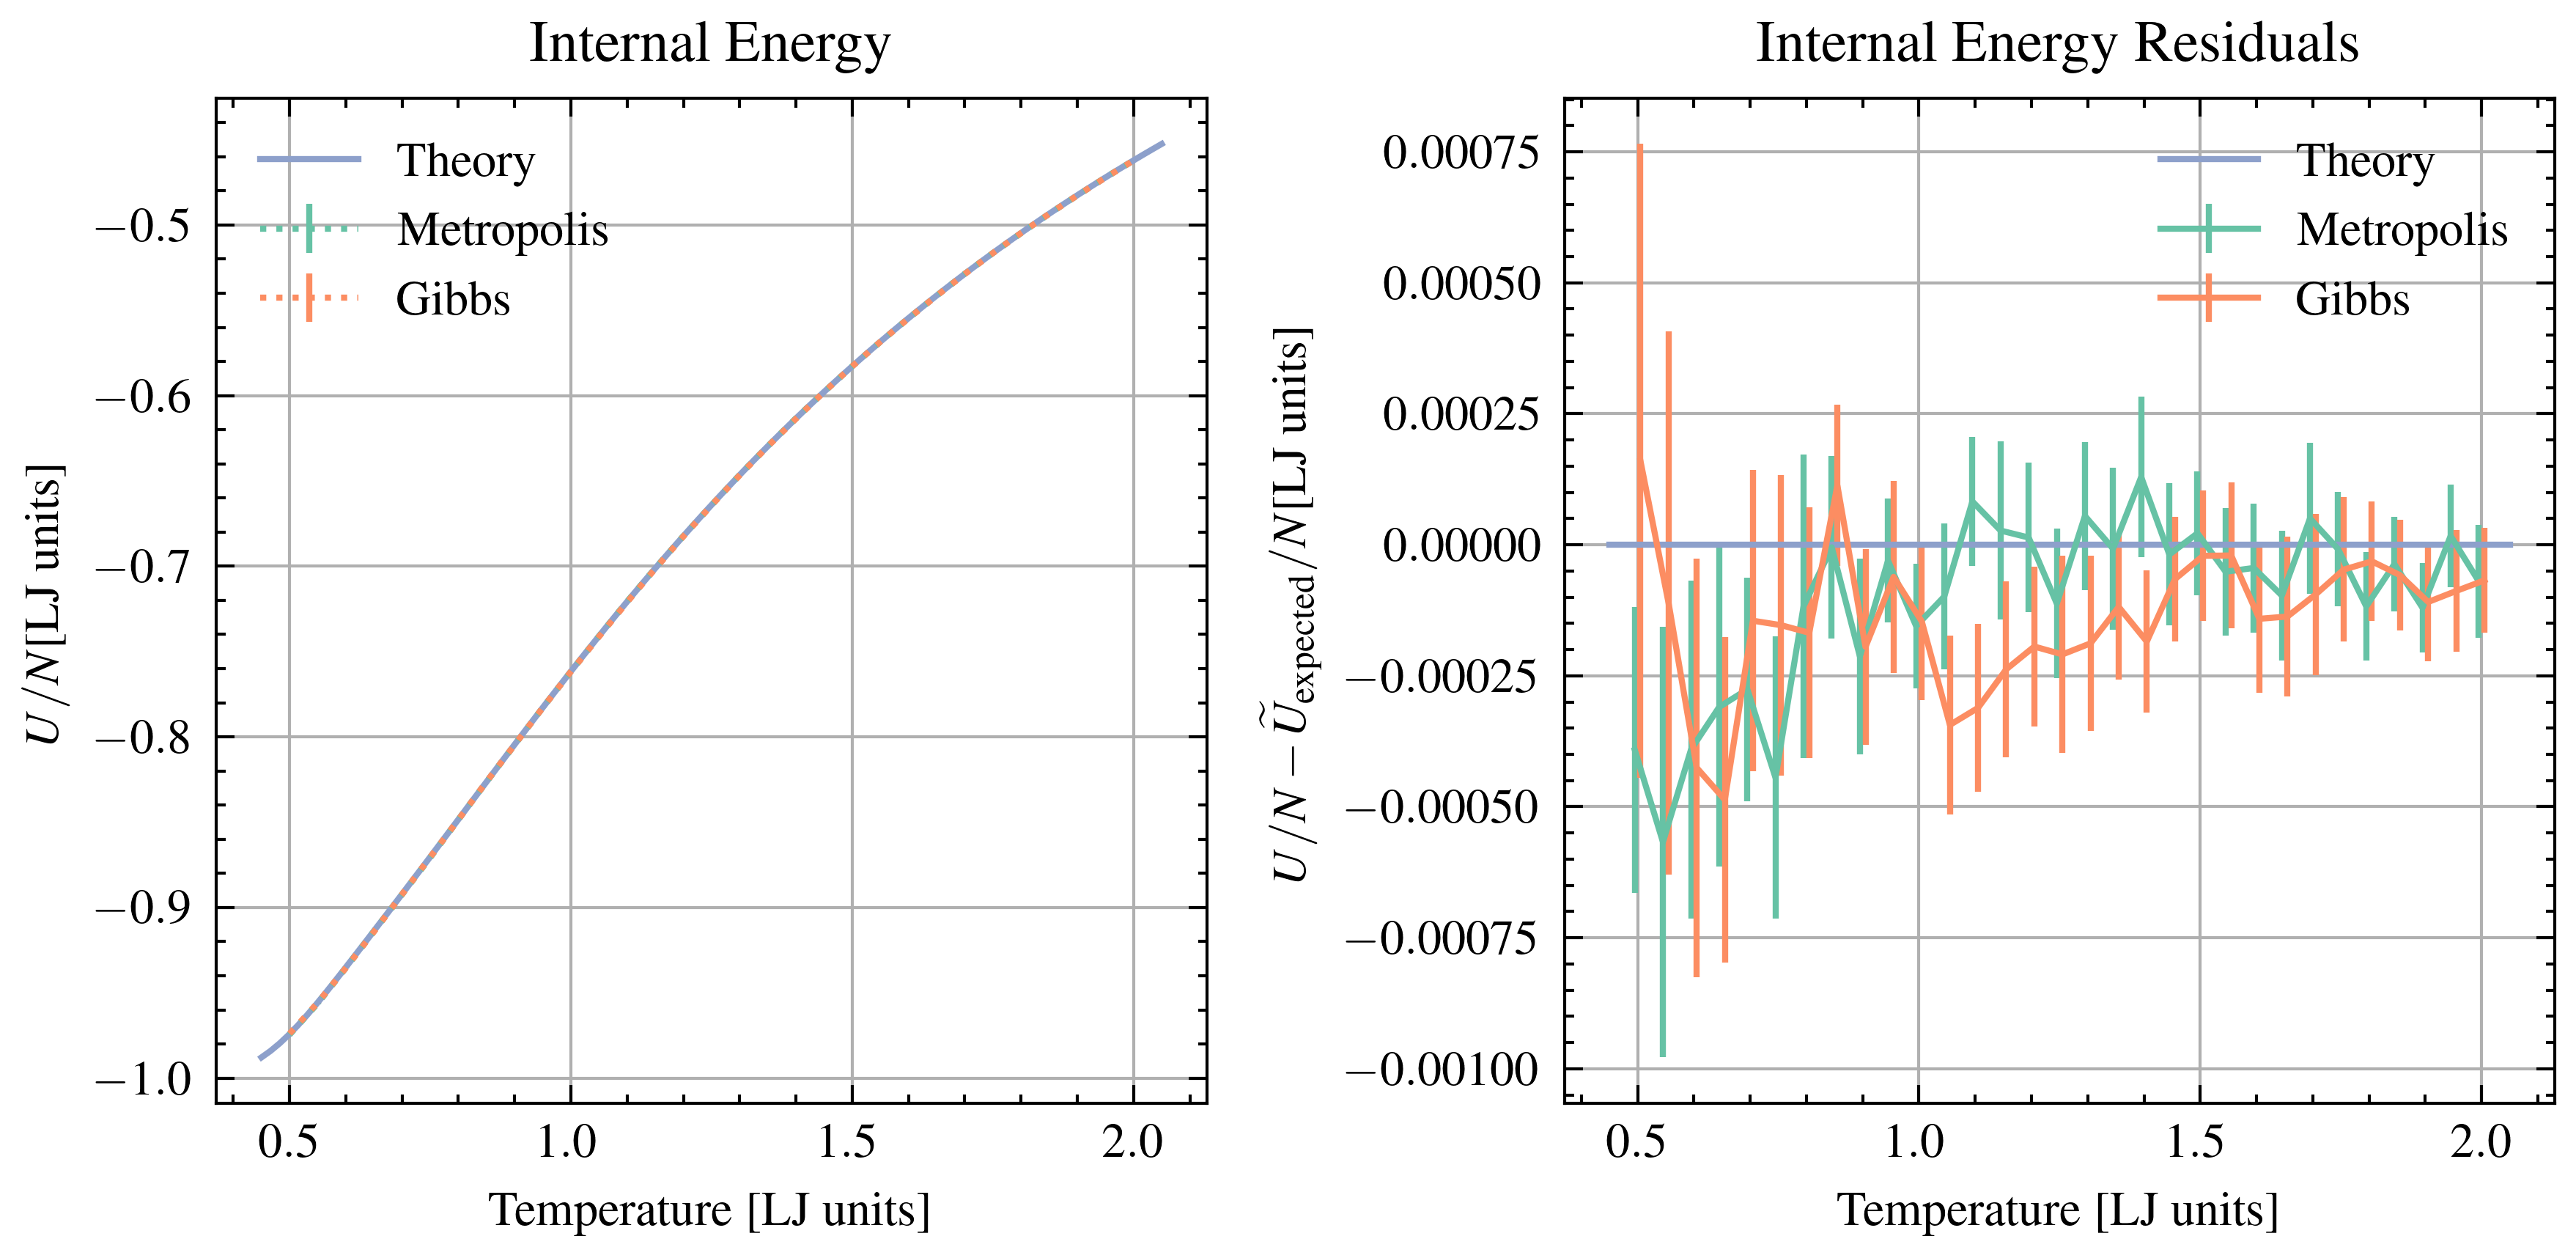

In [42]:
plot_with_residuals(
    "../Exercises/Exercises_06/Exer_06_01/RESULTS/total_energy",
    temperatures,
    0,
    "Energy",
)

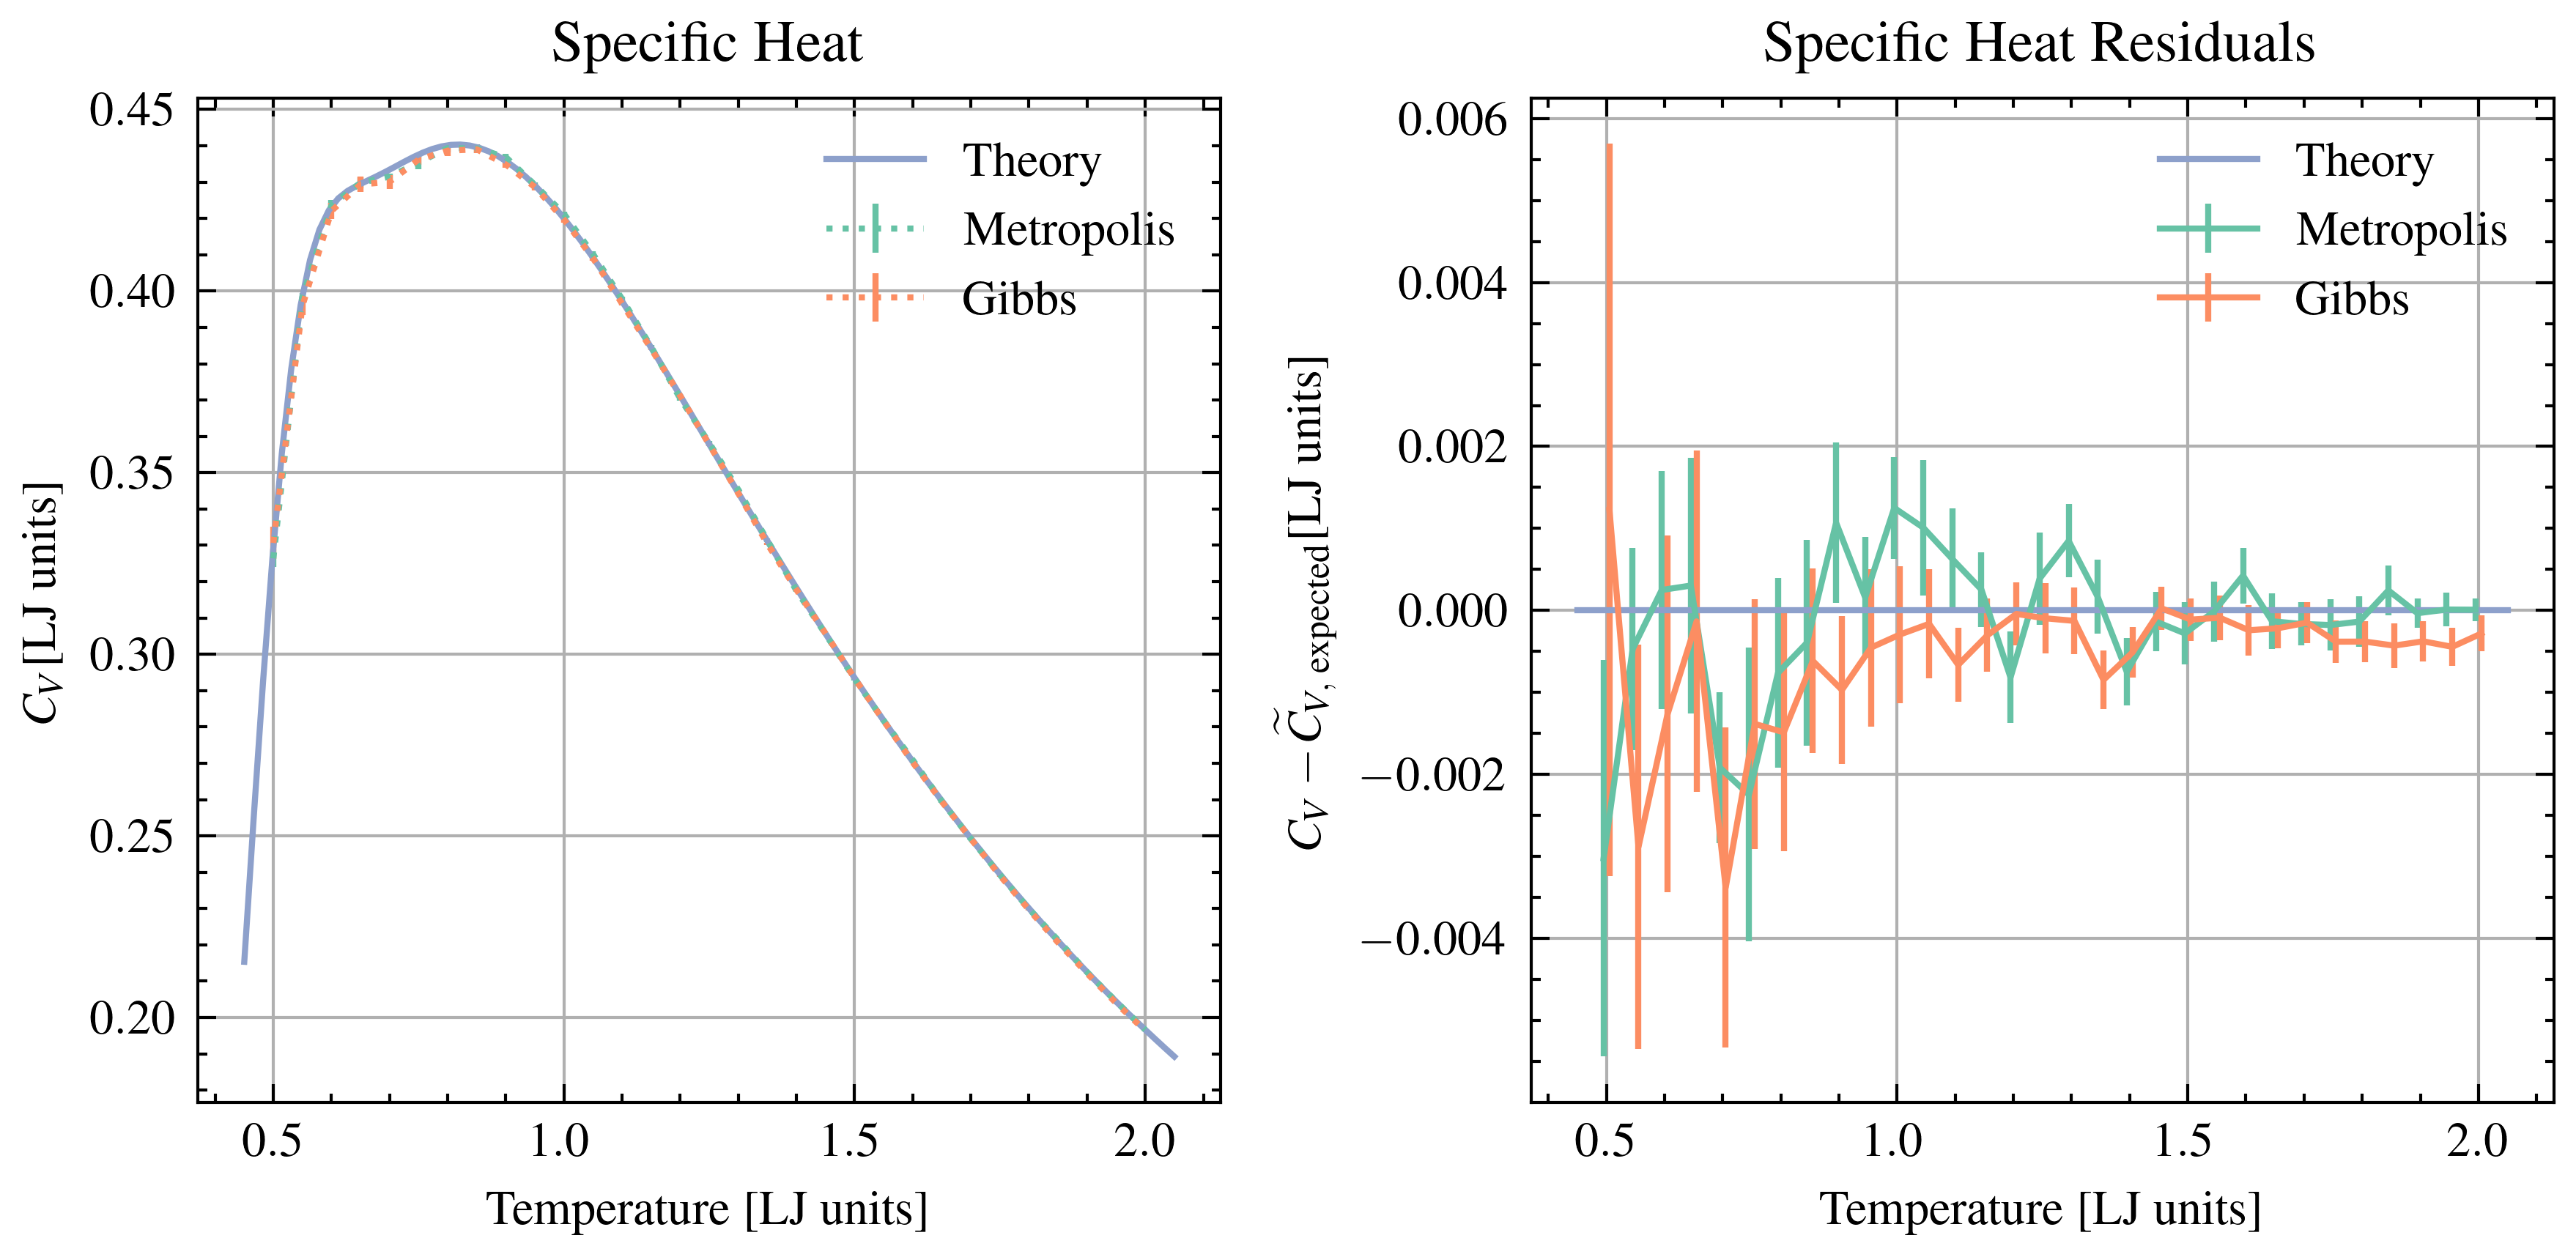

In [43]:
plot_with_residuals(
    "../Exercises/Exercises_06/Exer_06_01/RESULTS/specific_heat",
    temperatures,
    0,
    "Specific Heat",
)

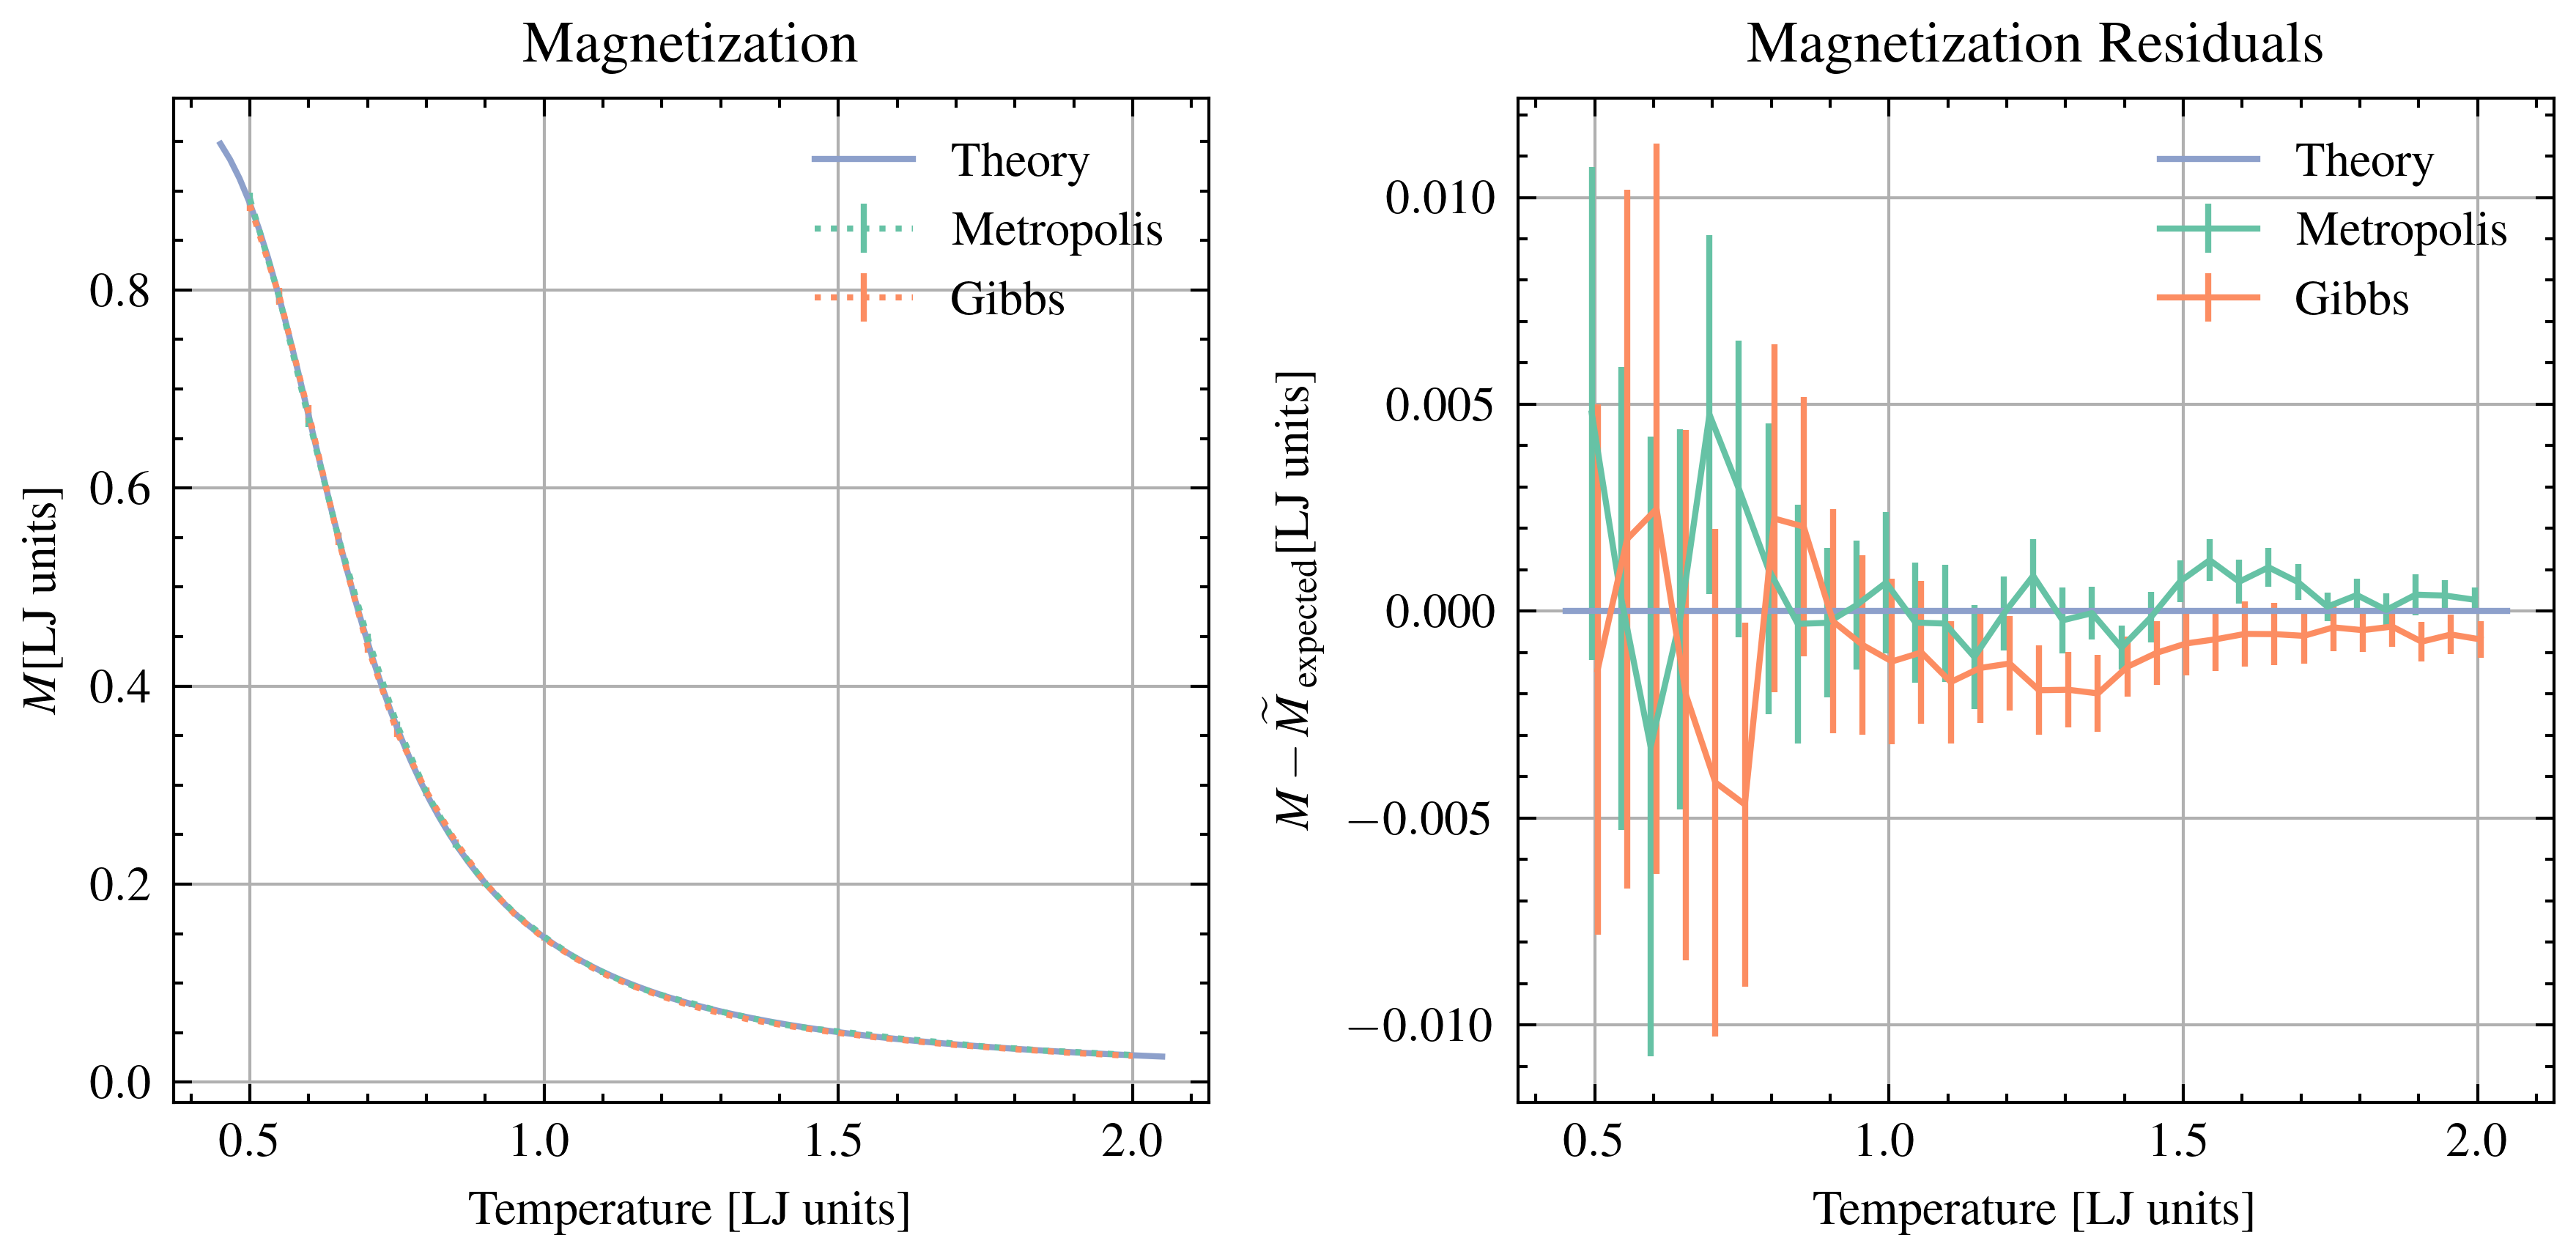

In [44]:
plot_with_residuals(
    "../Exercises/Exercises_06/Exer_06_01/RESULTS/magnetization",
    temperatures,
    0.02,
    "Magnetization",
)

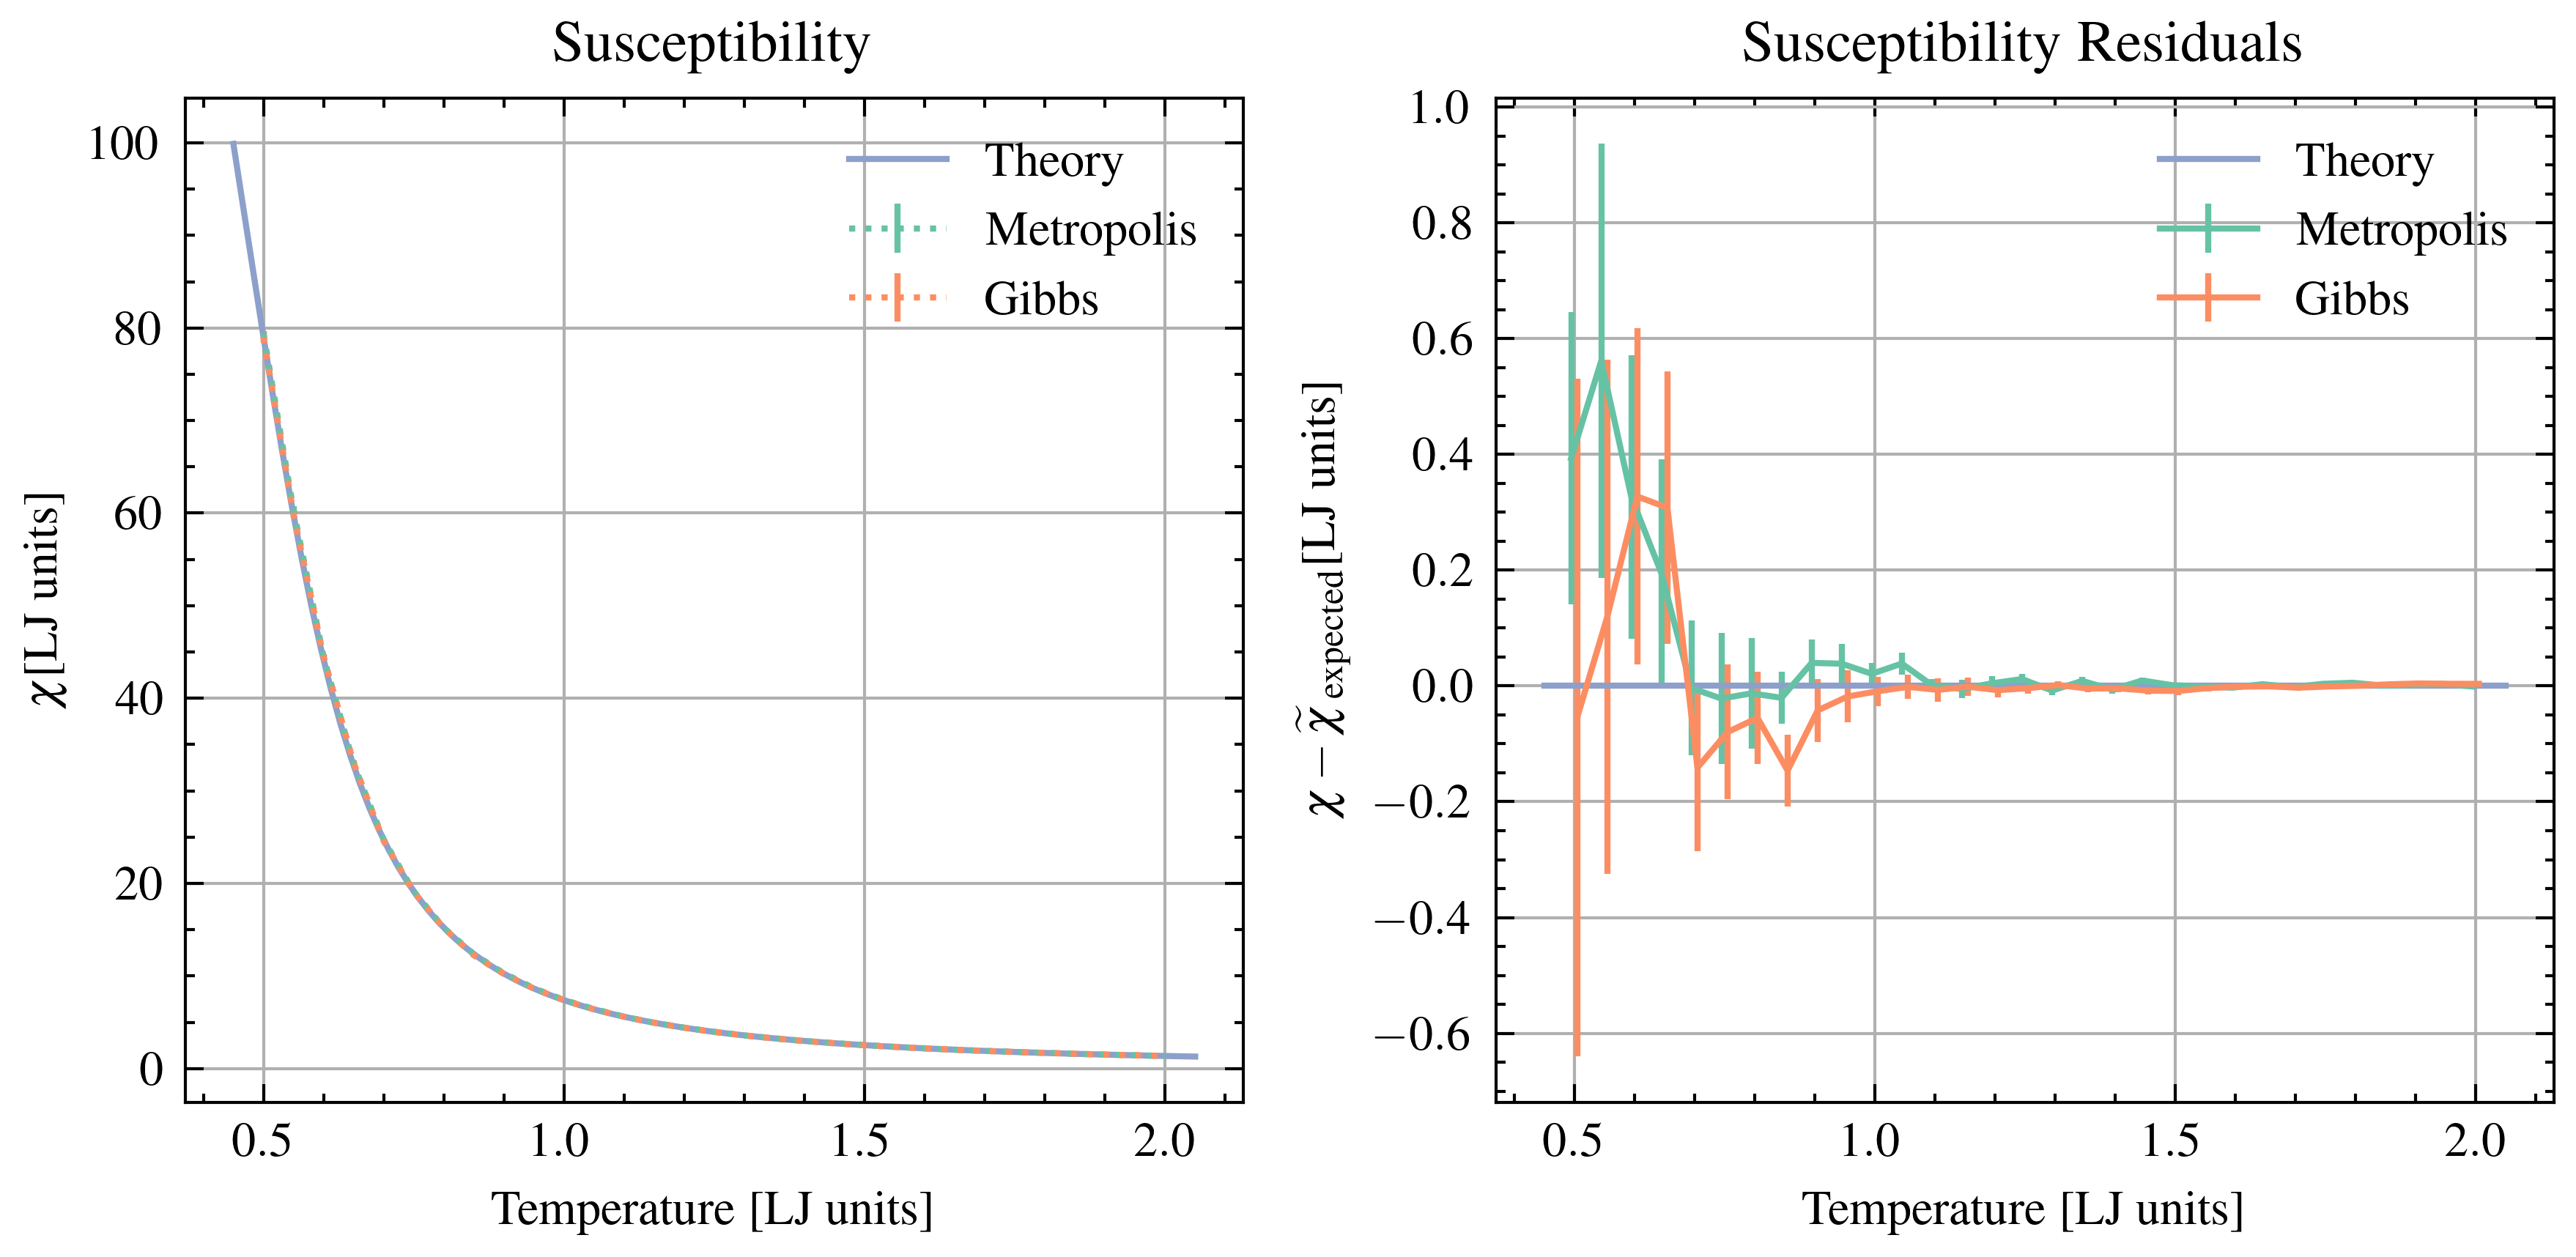

In [45]:
plot_with_residuals(
    "../Exercises/Exercises_06/Exer_06_01/RESULTS/susceptibility",
    temperatures,
    0,
    "Susceptibility",
)

We can notice that our simulation is statistically near the theoretical value. 

We can also notice that the errors increase for lower temperatures, that's because with lower temperatures both Metropolis and Gibbs make less changes to the spin values, this results in high variance.